In [2]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/My Drive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [4]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [5]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [6]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


**Feature Engineering**

In [7]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [8]:
import numpy as np

df['hour_sin'] = np.sin (2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos (2 * np.pi * df['transaction_hour']/24)

In [9]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [10]:
Feature = ['amount', 'hour_sin', 'hour_cos', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data training adalah {len(X_train)} dan jumlah data uji adalah {len(X_test)}")

Jumlah data training adalah 8000 dan jumlah data uji adalah 2000


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
num_transform = scaler

In [14]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [16]:
dimensi_input = X_train_processed.shape[1]
print(f"Jumlah fitur setelah  preprocessing: {dimensi_input}")

Jumlah fitur setelah  preprocessing: 8


**Model Baseline**

In [51]:
import keras

def model_dasar(input_dim, optimizer='adam', loss='binary_crossentropy', metrics=None):
  model = keras.Sequential([
      keras.Input(shape=[input_dim]),
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dropout(0.3),
      keras.layers.Dense(32, activation='relu'),
      keras.layers.Dropout(0.2),
      keras.layers.Dense(1, activation='sigmoid')
  ])
  model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
  return model
dimensi_fitur = X_train.shape[1]

In [35]:
!pip install scikeras

In [55]:
print("="*30 + "\n1. MODEL BASELINE\n" + "="*30)
model_base = model_dasar(dimensi_input)
model_base.fit(X_train_processed, y_train, epochs=20, batch_size=64, verbose=0)
y_pred_base = (model_base.predict(X_test_processed) > 0.5).astype(int)

1. MODEL BASELINE
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [61]:
y_pred_prob_base = model_base.predict(X_test_processed)
y_pred_base = (y_pred_prob_base > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

accuracy_baseline = accuracy_score(y_test, y_pred_base)
precision_baseline = precision_score(y_test, y_pred_base)
recall_baseline = recall_score(y_test, y_pred_base)
f1_baseline = f1_score(y_test, y_pred_base)
print(f"Akurasi Baseline: {accuracy_baseline:.4f}")
print(f"Precision Baseline: {precision_baseline:.4f}")
print(f"Recall Baseline: {recall_baseline:.4f}")
print(f"F1-Score Baseline: {f1_baseline:.4f}")

Akurasi Baseline: 0.9915
Precision Baseline: 0.7407
Recall Baseline: 0.6667
F1-Score Baseline: 0.7018


In [64]:
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.74      0.67      0.70        30

    accuracy                           0.99      2000
   macro avg       0.87      0.83      0.85      2000
weighted avg       0.99      0.99      0.99      2000



In [67]:
roc_auc_baseline = roc_auc_score(y_test, y_pred_prob_base)
print(f"ROC AUC Baseline : {roc_auc_baseline:.4f}")

ROC AUC Baseline : 0.9947


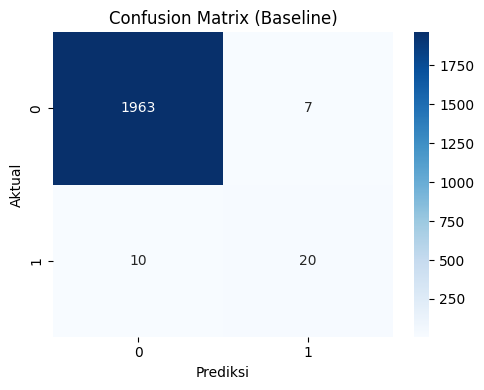

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Class_Weight**

In [70]:
from sklearn.utils.class_weight import compute_class_weight

bobot = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
dict_bobot = {0: bobot[0], 1: bobot[1]}

In [75]:
print("="*40 + '\n2. Model Class_Weight\n' + "="*40)
mlp_cw = model_dasar(dimensi_input)
mlp_cw.fit(X_train_processed, y_train,class_weight=dict_bobot, epochs=20, batch_size=64, verbose=0)

2. Model Class_Weight


In [77]:
y_prob_cw = mlp_cw.predict(X_test_processed).flatten()
y_pred_cw = (y_prob_cw > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [78]:
accuracy_cw = accuracy_score(y_test, y_pred_cw)
precision_cw = precision_score(y_test, y_pred_cw)
recall_cw = recall_score(y_test, y_pred_cw)
f1_cw = f1_score(y_test, y_pred_cw)
print(f'Akurasi Class Weight: {accuracy_cw:.4f}')
print(f'Precision Class Weight: {precision_cw:.4f}')
print(f'Recall Class Weight: {recall_cw:.4f}')
print(f'F1-Score Class Weight: {f1_cw:.4f}')

Akurasi Class Weight: 0.9690
Precision Class Weight: 0.3222
Recall Class Weight: 0.9667
F1-Score Class Weight: 0.4833


In [79]:
print(classification_report(y_test, y_pred_cw))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1970
           1       0.32      0.97      0.48        30

    accuracy                           0.97      2000
   macro avg       0.66      0.97      0.73      2000
weighted avg       0.99      0.97      0.98      2000



In [80]:
roc_auc_cw = roc_auc_score(y_test, y_prob_cw)
print(f"ROC AUC Class Weight: {roc_auc_cw:.4f}")

ROC AUC Class Weight: 0.9954


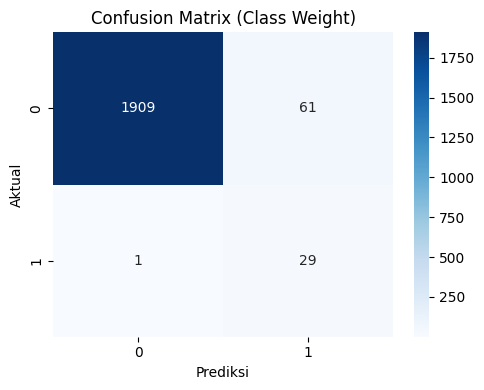

In [81]:
cm_cw = confusion_matrix(y_test, y_pred_cw)
plt.figure(figsize=(5,4))
sns.heatmap(cm_cw, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Class Weight)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model SMOTE**

In [82]:
from imblearn.over_sampling import SMOTE
print("="*40 + "\n3. Model SMOTE\n" + "="*40)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
print(f"Jumlah data setelah SMOTE: Kelas 0 = {sum(y_train_smote==0)}, Kelas 1 = {sum(y_train_smote==1)}\n")

3. Model SMOTE
Jumlah data setelah SMOTE: Kelas 0 = 7879, Kelas 1 = 7879



In [83]:
model_smote = model_dasar(dimensi_input)
model_smote.fit(X_train_smote,
                y_train_smote,
                epochs=20,
                batch_size=64,
                verbose=0)

In [84]:
y_prob_smote = model_smote.predict(X_test_processed).flatten()
y_pred_smote = (y_prob_smote > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [86]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
print(f"Akurasi SMOTE : {accuracy_smote:.4f}")
print(f"Precision SMOTE : {precision_smote:.4f}")
print(f"Recall SMOTE : {recall_smote:.4f}")
print(f"F1-Score SMOTE : {f1_smote:.4f}")

Akurasi SMOTE : 0.9875
Precision SMOTE : 0.5490
Recall SMOTE : 0.9333
F1-Score SMOTE : 0.6914


In [88]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.55      0.93      0.69        30

    accuracy                           0.99      2000
   macro avg       0.77      0.96      0.84      2000
weighted avg       0.99      0.99      0.99      2000



In [87]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f"ROC AUC SMOTE : {roc_auc_smote:.4f}")

ROC AUC SMOTE : 0.9955


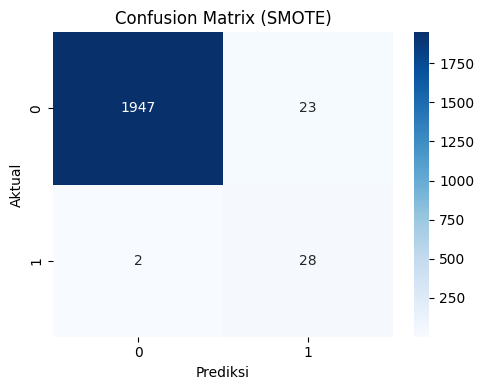

In [90]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

**Keras-Tuner dengan model Baseline**

In [93]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00


In [95]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train.to_numpy())

In [97]:
# Validasi Normalization
print("Mean :", normalizer.mean.numpy() )
print("Variance :", normalizer.variance.numpy())

Mean : [[ 1.7536147e+02 -1.3361504e-02 -2.7415012e-03  9.8499998e-02
   8.5000001e-02  6.1993999e+01  2.0078750e+00  4.3407749e+01]]
Variance : [[3.0525799e+04 5.0327271e-01 4.9654123e-01 8.8797748e-02 7.7775002e-02
  4.6189795e+02 2.0710630e+00 2.2417200e+02]]


In [114]:
def build_tuner_model(hp):
  # RAW Input
  num_input = tf.keras.Input(shape=[dimensi_input])

  # Preprocessin Numerik (Normalization)
  x = normalizer(num_input)
  activation_choice = hp.Choice('activation', values=['relu', 'elu', 'tanh'])

  # Hidden Layers
  for i in range(hp.Int('num_layers', 1, 6)):
    x = tf.keras.layers.Dense(
        units=hp.Int(f"units_{i}", min_value=64, max_value=256, step=32),
        use_bias = False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation(activation_choice)(x)
    x = tf.keras.layers.Dropout(hp.Float(f"dropout_{i}", min_value=0.1, max_value=0.5, step=0.1))(x)

  # Layers Output
  output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

  # Kunci model
  model = tf.keras.Model(inputs=num_input, outputs=output)
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
  model.compile(
      optimizer= tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
      loss='binary_crossentropy',
      metrics=['accuracy',
               tf.keras.metrics.AUC(name="auc"),
               tf.keras.metrics.Precision(name="precision"),
               tf.keras.metrics.Recall(name="recall")]
  )
  return model

In [117]:
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective=kt.Objective("val_auc", direction='max'),
    max_trials =70,
    executions_per_trial = 2,
    directory="mlp_nas",
    project_name = "Skripsi_DDoS_Detection",
    overwrite=True
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        min_delta = 1e-4,
        verbose = 1,
        restore_best_weights=True
    )

]

In [118]:
tuner.search(
    x=X_train.to_numpy(),
    y=y_train.to_numpy(),
    epochs=50,
    validation_split=0.2,
    batch_size=64,
    callbacks=callbacks
)

Trial 70 Complete [00h 01m 46s]
val_auc: 0.9984689652919769

Best val_auc So Far: 0.9991549849510193
Total elapsed time: 01h 40m 28s


In [119]:
top_3_hps = tuner.get_best_hyperparameters(num_trials=3)

best_1_hps = top_3_hps[0]
best_2_hps = top_3_hps[1]
best_3_hps = top_3_hps[2]

In [120]:
for i, hp in enumerate(top_3_hps):
  print(f"\n{'='*40}")
  print(f" Hasil  Terbaik peringkat :{i+1}")
  print(f"{'='*40}")

  num_layers = hp.get('num_layers')
  lr = hp.get('learning_rate')

  print(f"Jumlah layers : {num_layers}")
  print(f"Learning Rate : {lr:.6f}")

  for j in range(num_layers):
    units_key = f'units_{j}'
    act_key = f'activation_{j}'
    drop_key = f'dropout_{j}'

    units = hp.get(units_key) if units_key in hp.values else "N/A"
    act = hp.get(act_key) if act_key in hp.values else "N/A"

    if drop_key in hp.values:
      drop_val = hp.get(drop_key)
      print(f" - Layer {j} : {units} units | {act} | Dropout :{drop_val:.2f}")
    else:
      print(f" - Layer {j} : {units} units | {act} | No Dropout")



 Hasil  Terbaik peringkat :1
Jumlah layers : 1
Learning Rate : 0.010000
 - Layer 0 : 128 units | N/A | Dropout :0.10

 Hasil  Terbaik peringkat :2
Jumlah layers : 3
Learning Rate : 0.010000
 - Layer 0 : 96 units | N/A | Dropout :0.10
 - Layer 1 : 64 units | N/A | Dropout :0.30
 - Layer 2 : 96 units | N/A | Dropout :0.30

 Hasil  Terbaik peringkat :3
Jumlah layers : 5
Learning Rate : 0.010000
 - Layer 0 : 192 units | N/A | Dropout :0.10
 - Layer 1 : 96 units | N/A | Dropout :0.40
 - Layer 2 : 128 units | N/A | Dropout :0.10
 - Layer 3 : 64 units | N/A | Dropout :0.10
 - Layer 4 : 256 units | N/A | Dropout :0.20


In [121]:
best_mlp = tuner.hypermodel.build(best_1_hps)
best_mlp.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,682 (6.57 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 273 (1.07 KB)

In [122]:
callbacks_retraining = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience = 10,
        min_delta = 1e-4,
        verbose = 1,
        restore_best_weights=True
    )
]

In [124]:
history = best_mlp.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    epochs = 100,
    validation_data=(X_test.to_numpy(), y_test.to_numpy()),
    callbacks=callbacks_retraining,
    verbose = 1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9755 - auc: 0.9138 - loss: 0.0733 - precision: 0.2340 - recall: 0.2727 - val_accuracy: 0.9875 - val_auc: 0.9942 - val_loss: 0.0268 - val_precision: 0.5714 - val_recall: 0.6667
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9874 - auc: 0.9681 - loss: 0.0360 - precision: 0.6111 - recall: 0.4545 - val_accuracy: 0.9855 - val_auc: 0.9905 - val_loss: 0.0303 - val_precision: 0.5161 - val_recall: 0.5333
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9864 - auc: 0.9831 - loss: 0.0333 - precision: 0.5750 - recall: 0.3802 - val_accuracy: 0.9895 - val_auc: 0.9932 - val_loss: 0.0254 - val_precision: 0.6452 - val_recall: 0.6667
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9887 - auc: 0.9925 - loss: 0.0257 - precision: 0.6742 - recall: 0.4959 - val_accuracy: 0.9825 - val_auc: 0.9928 - val_loss: 0.0412 - val_precision: 0.4528 - val_recall: 0.8000
Epoch 5/100
250/250 ━━━━━━

In [127]:
loss, acc, auc, prec, rec = best_mlp.evaluate(X_test.to_numpy(), y_test.to_numpy())

print(f"Akurasi model adalah : {acc:.4f}")
print(f"Loss model adalah : {loss:.4f}" )
print(f"Precision model adalah : {prec:.4f}")
print(f"Recall model adalah : {rec:.4f}")
print(f"AUC model adalah : {auc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9960 - auc: 0.9992 - loss: 0.0093 - precision: 0.8667 - recall: 0.8667
Akurasi model adalah : 0.9960
Loss model adalah : 0.0093
Precision model adalah : 0.8667
Recall model adalah : 0.8667
AUC model adalah : 0.9992


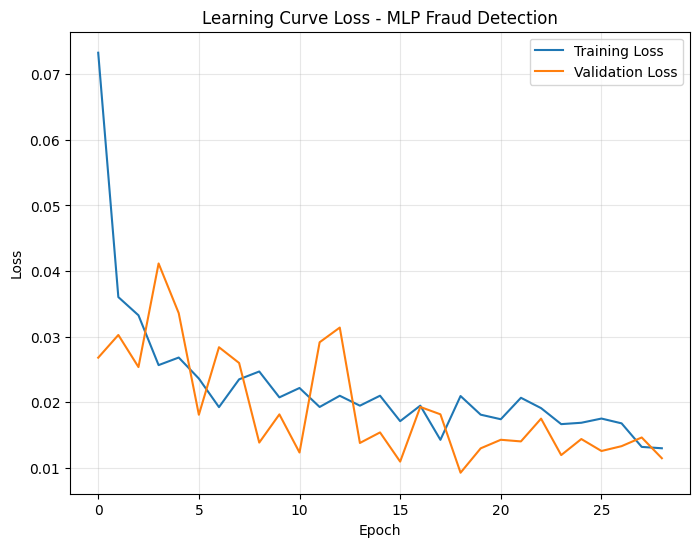

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Learning curve
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],
         label='Training Loss')
plt.plot(history.history['val_loss'],
         label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve Loss - MLP Fraud Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

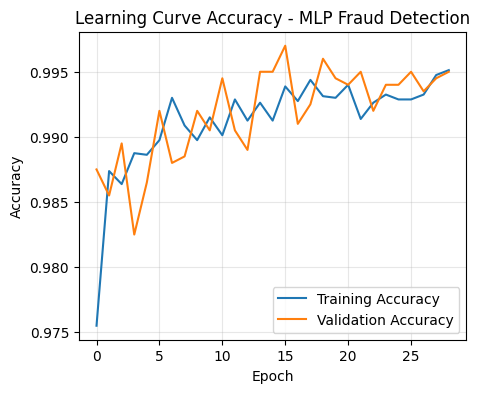

In [129]:
# Learning Curve Accuracy
plt.figure(figsize=(5,4))
plt.plot(history.history['accuracy'],
         label='Training Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve Accuracy - MLP Fraud Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [130]:
y_pred_prob = best_mlp.predict(X_test.to_numpy()).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [131]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Akurasi model adalah : {accuracy:.4f}")
print(f"Precision model adalah : {precision:.4f}")
print(f"Recall model adalah : {recall:.4f}")
print(f"F1-Score model adalah : {f1:.4f}")

Akurasi model adalah : 0.9960
Precision model adalah : 0.8667
Recall model adalah : 0.8667
F1-Score model adalah : 0.8667


In [132]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC model adalah : {roc_auc:.4f}")

ROC AUC model adalah : 0.9992


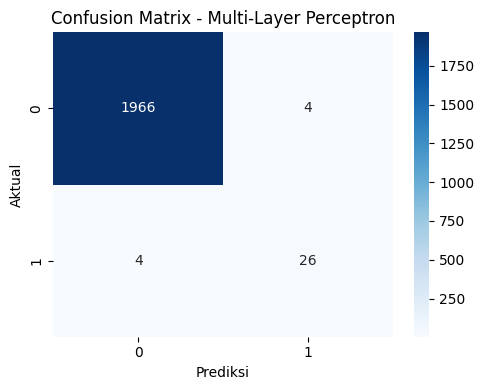

In [133]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Multi-Layer Perceptron')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [135]:
def keras_auc_score(estimator, X, y):
  y_prob = estimator.predict(X, verbose=0).flatten()
  return roc_auc_score(y, y_prob)

In [138]:
from sklearn.inspection import permutation_importance

hasil = permutation_importance(
    estimator=best_mlp,
    X=X_test.to_numpy(),
    y=y_test.to_numpy(),
    scoring=keras_auc_score,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [141]:
nama_kolom = X_test.columns

df_importance = pd.DataFrame({
    'Fitur': nama_kolom,
    'Importance_mean': hasil.importances_mean,
    'Importance_std': hasil.importances_std
})

df_importance = df_importance.sort_values(by='Importance_mean', ascending=False)

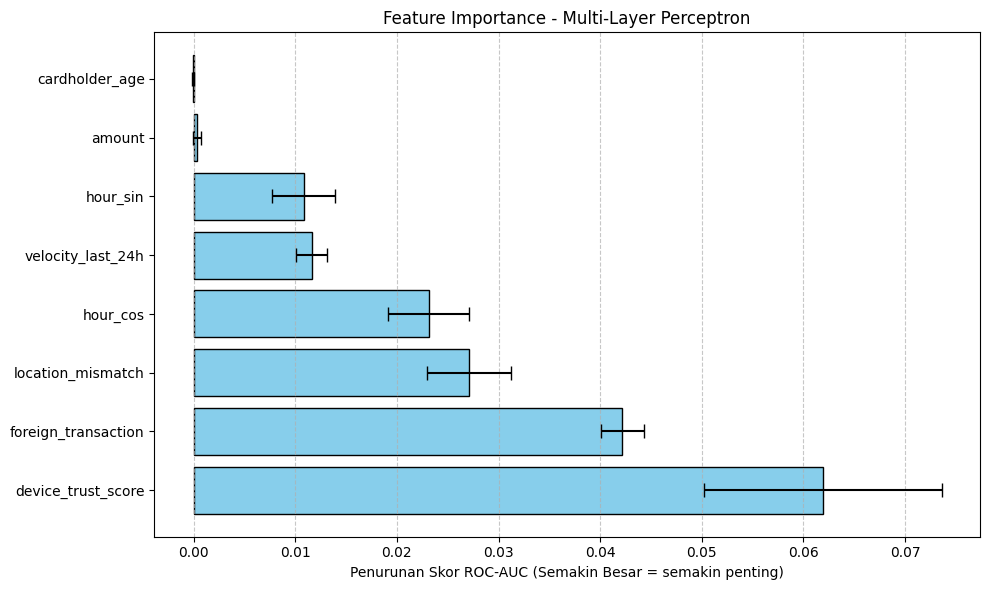

In [142]:
plt.figure(figsize=(10,6))
plt.barh(df_importance['Fitur'], df_importance['Importance_mean'], xerr=df_importance['Importance_std'], capsize=5, color='skyblue',edgecolor='black')
plt.xlabel('Penurunan Skor ROC-AUC (Semakin Besar = semakin penting)')
plt.title('Feature Importance - Multi-Layer Perceptron')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [143]:
from google.colab import files
import joblib

joblib.dump(best_mlp, 'Multi-Layer Perceptron.joblib')
files.download('Multi-Layer Perceptron.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>